In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import random
from tqdm import tqdm

In [2]:
# Paths to train and test folders
train_folder_path = r"C:\Users\Shash\Desktop\Hackathon+  Projects\Indian Birds Classification\Birds_Dataset\train"
test_folder_path = r"C:\Users\Shash\Desktop\Hackathon+  Projects\Indian Birds Classification\Birds_Dataset\valid"
label_dict = {}

In [3]:
def load_images_from_folder(folder_path, image_paths_list, labels_list, label_dict):
    folders = os.listdir(folder_path)
    
    for bird_name in tqdm(folders, desc=f"Loading from {os.path.basename(folder_path)}"):
        bird_folder = os.path.join(folder_path, bird_name)
        if os.path.isdir(bird_folder):
            if bird_name not in label_dict:
                label_dict[bird_name] = len(label_dict)
            for filename in os.listdir(bird_folder):
                if filename.endswith('.jpg') or filename.endswith('.png'):
                    image_paths_list.append(os.path.join(bird_folder, filename))
                    labels_list.append(label_dict[bird_name])
    
    print(f"Loaded {len(image_paths_list)} images from {os.path.basename(folder_path)}")

In [4]:
# Load training and testing data
train_image_paths, train_labels = [], []
test_image_paths, test_labels = [], []

load_images_from_folder(train_folder_path, train_image_paths, train_labels, label_dict)
load_images_from_folder(test_folder_path, test_image_paths, test_labels, label_dict)

Loading from train: 100%|██████████| 25/25 [00:00<00:00, 40.43it/s]


Loaded 30000 images from train


Loading from valid: 100%|██████████| 25/25 [00:00<00:00, 159.97it/s]

Loaded 7500 images from valid


In [5]:
print(f"Number of classes: {len(label_dict)}")
print(f"Class distribution in training set:")
for bird_name, label in label_dict.items():
    count = train_labels.count(label)
    print(f"  {bird_name}: {count} images")

Number of classes: 25
Class distribution in training set:
  Asian-Green-Bee-Eater: 1200 images
  Brown-Headed-Barbet: 1200 images
  Cattle-Egret: 1200 images
  Common-Kingfisher: 1200 images
  Common-Myna: 1200 images
  Common-Rosefinch: 1200 images
  Common-Tailorbird: 1200 images
  Coppersmith-Barbet: 1200 images
  Forest-Wagtail: 1200 images
  Gray-Wagtail: 1200 images
  Hoopoe: 1200 images
  House-Crow: 1200 images
  Indian-Grey-Hornbill: 1200 images
  Indian-Peacock: 1200 images
  Indian-Pitta: 1200 images
  Indian-Roller: 1200 images
  Jungle-Babbler: 1200 images
  Northern-Lapwing: 1200 images
  Red-Wattled-Lapwing: 1200 images
  Ruddy-Shelduck: 1200 images
  Rufous-Treepie: 1200 images
  Sarus-Crane: 1200 images
  White-Breasted-Kingfisher: 1200 images
  White-Breasted-Waterhen: 1200 images
  White-Wagtail: 1200 images


In [6]:
# Preprocess images function
def preprocess_image(image_path):
    image = cv2.imread(image_path)
    if image is not None:
        image = cv2.resize(image, (64, 64))
        image = image / 255.0
        return image
    else:
        return np.zeros((64, 64, 3))

In [7]:
# Preprocess training and testing images
print("Preprocessing training images...")
train_images = np.array([preprocess_image(path) for path in tqdm(train_image_paths)])
print("Preprocessing testing images...")
test_images = np.array([preprocess_image(path) for path in tqdm(test_image_paths)])
train_labels = np.array(train_labels)
test_labels = np.array(test_labels)

Preprocessing training images...


100%|██████████| 30000/30000 [07:38<00:00, 65.47it/s] 


Preprocessing testing images...


100%|██████████| 7500/7500 [01:30<00:00, 82.94it/s] 


In [8]:
# Using ImageDataGenerator for data augmentation
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

Visualizing data augmentation examples...


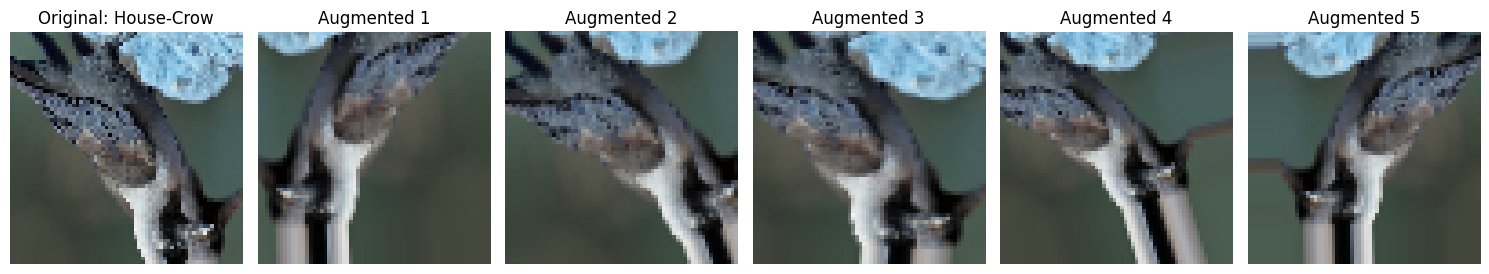

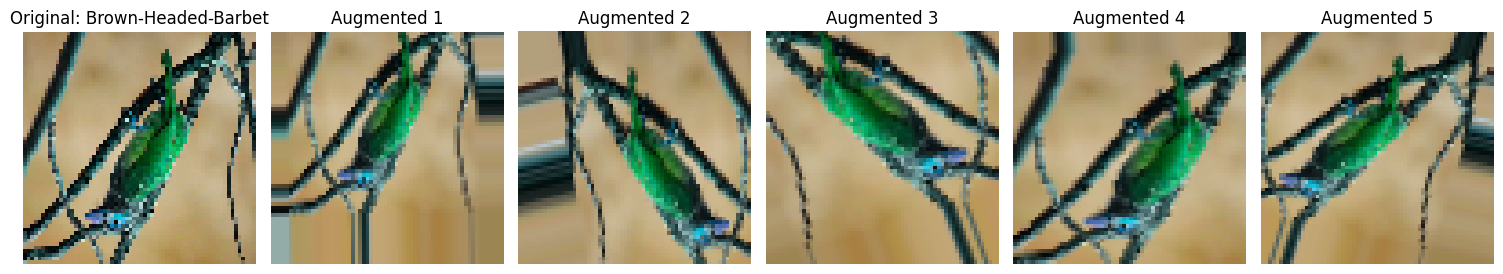

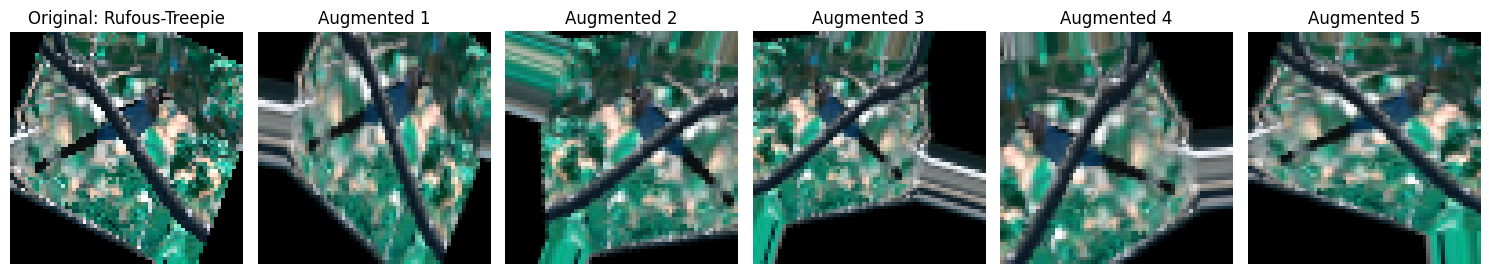

In [9]:
def visualize_augmentation(images, labels, label_dict, num_samples=3, num_augmentations=5):
    try:
        num_samples = min(num_samples, len(images))
        indices = random.sample(range(len(images)), num_samples)
        
        for idx in indices:
            plt.figure(figsize=(15, 3))
            image = images[idx:idx+1]
            bird_name = next(name for name, val in label_dict.items() if val == labels[idx])
            
            # Original image
            plt.subplot(1, num_augmentations+1, 1)
            plt.imshow(images[idx])
            plt.title(f"Original: {bird_name}")
            plt.axis('off')
            
            # Augmented versions
            aug_iterator = datagen.flow(image, batch_size=1)
            for i in range(num_augmentations):
                aug_image = next(aug_iterator)[0]
                plt.subplot(1, num_augmentations+1, i+2)
                plt.imshow(aug_image)
                plt.title(f"Augmented {i+1}")
                plt.axis('off')
            
            plt.tight_layout()
            plt.show()
            
    except Exception as e:
        print(f"Error during visualization: {str(e)}")

# Visualize some augmented images
print("Visualizing data augmentation examples...")
visualize_augmentation(train_images, train_labels, label_dict)

In [10]:
# Model definition with Batch Normalization
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(len(label_dict), activation='softmax')
])

c:\Users\Shash\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
# Compile the model with a lower learning rate
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [12]:
# Callbacks for early stopping and saving the best model
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, verbose=1),
    ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

In [13]:
# Create a directory for model checkpoints if it doesn't exist
checkpoint_dir = './model_checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

# Train the model with augmented data
history = model.fit(datagen.flow(train_images, train_labels, batch_size=32),
          validation_data=(test_images, test_labels),
          epochs=20,
          callbacks=[
              EarlyStopping(monitor='val_loss', patience=5, verbose=1),
              ModelCheckpoint(os.path.join(checkpoint_dir, 'best_model.keras'), 
                            monitor='val_accuracy', 
                            save_best_only=True, 
                            verbose=1)
          ],
          verbose=1)

Epoch 1/20


c:\Users\Shash\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


938/938 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step - accuracy: 0.0718 - loss: 3.3627
Epoch 1: val_accuracy improved from -inf to 0.11547, saving model to ./model_checkpoints\best_model.keras
938/938 ━━━━━━━━━━━━━━━━━━━━ 383s 393ms/step - accuracy: 0.0718 - loss: 3.3623 - val_accuracy: 0.1155 - val_loss: 2.7402
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.1111 - loss: 2.8263
Epoch 2: val_accuracy improved from 0.11547 to 0.14853, saving model to ./model_checkpoints\best_model.keras
938/938 ━━━━━━━━━━━━━━━━━━━━ 260s 275ms/step - accuracy: 0.1111 - loss: 2.8262 - val_accuracy: 0.1485 - val_loss: 2.5891
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.1441 - loss: 2.6885
Epoch 3: val_accuracy did not improve from 0.14853
938/938 ━━━━━━━━━━━━━━━━━━━━ 249s 264ms/step - accuracy: 0.1441 - loss: 2.6884 - val_accuracy: 0.1433 - val_loss: 2.8747
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.1893 - loss: 2.5328
Epoch 4: val_accuracy improved

In [14]:
# Evaluation of the model on training and testing data
print("Evaluating CNN model...")
train_loss, train_accuracy = model.evaluate(train_images, train_labels, verbose=1)
test_loss, test_accuracy = model.evaluate(test_images, test_labels, verbose=1)

print(f'CNN Training Accuracy: {train_accuracy * 100:.2f}%')
print(f'CNN Training Loss: {train_loss:.4f}')
print(f'CNN Testing Accuracy: {test_accuracy * 100:.2f}%')
print(f'CNN Testing Loss: {test_loss:.4f}')

Evaluating CNN model...
938/938 ━━━━━━━━━━━━━━━━━━━━ 32s 34ms/step - accuracy: 0.6848 - loss: 0.9830
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - accuracy: 0.6555 - loss: 1.0755
CNN Training Accuracy: 66.53%
CNN Training Loss: 1.0441
CNN Testing Accuracy: 64.93%
CNN Testing Loss: 1.1110


In [15]:
# Get predictions for test data
test_predictions = model.predict(test_images)
test_predictions_labels = np.argmax(test_predictions, axis=1)

235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step


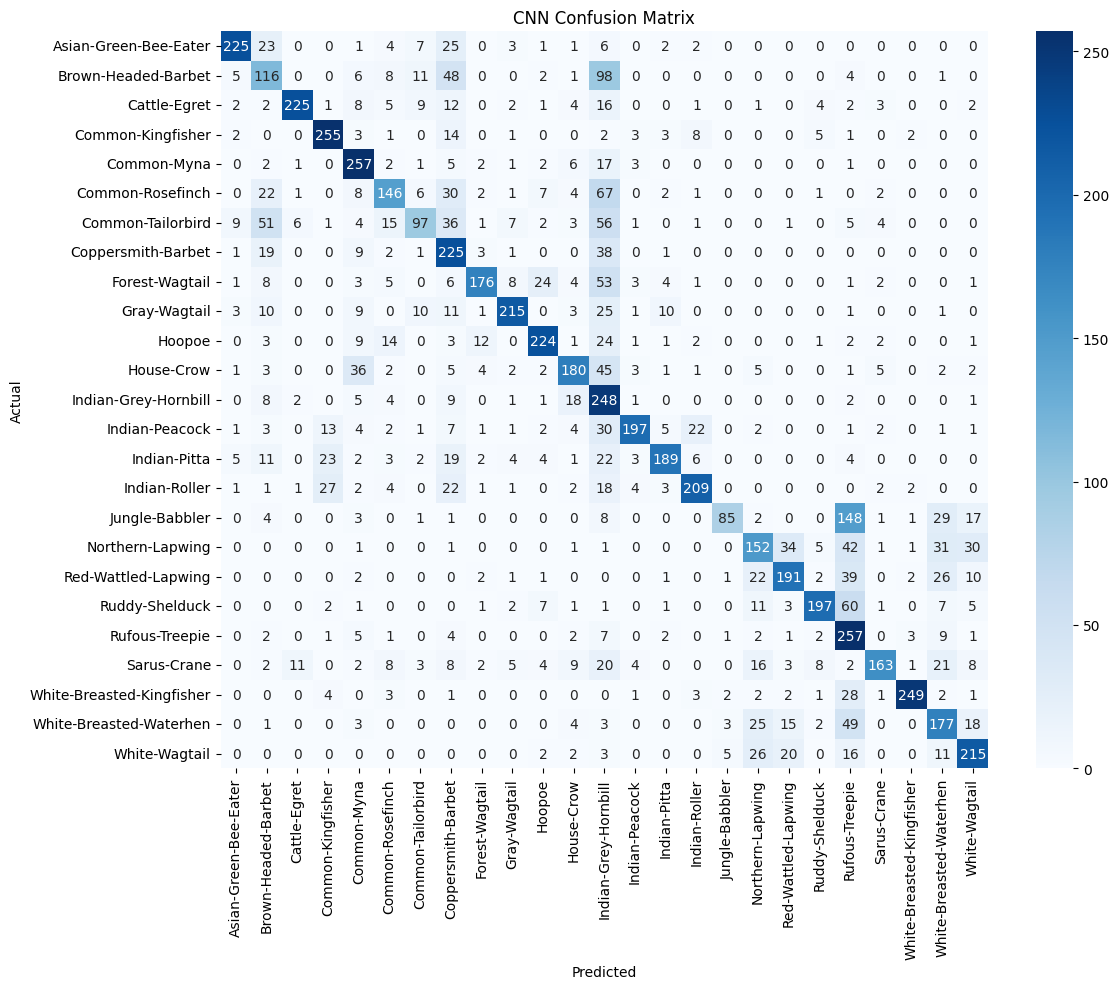

In [16]:
# Generate and plot confusion matrix
conf_matrix = confusion_matrix(test_labels, test_predictions_labels)
plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=list(label_dict.keys()), 
            yticklabels=list(label_dict.keys()))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('CNN Confusion Matrix')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [17]:
# Display classification report
print("CNN Classification Report:")
print(classification_report(test_labels, test_predictions_labels, target_names=label_dict.keys()))

CNN Classification Report:
                           precision    recall  f1-score   support

    Asian-Green-Bee-Eater       0.88      0.75      0.81       300
      Brown-Headed-Barbet       0.40      0.39      0.39       300
             Cattle-Egret       0.91      0.75      0.82       300
        Common-Kingfisher       0.78      0.85      0.81       300
              Common-Myna       0.67      0.86      0.75       300
         Common-Rosefinch       0.64      0.49      0.55       300
        Common-Tailorbird       0.65      0.32      0.43       300
       Coppersmith-Barbet       0.46      0.75      0.57       300
           Forest-Wagtail       0.84      0.59      0.69       300
             Gray-Wagtail       0.84      0.72      0.77       300
                   Hoopoe       0.78      0.75      0.76       300
               House-Crow       0.72      0.60      0.65       300
     Indian-Grey-Hornbill       0.31      0.83      0.45       300
           Indian-Peacock       0.

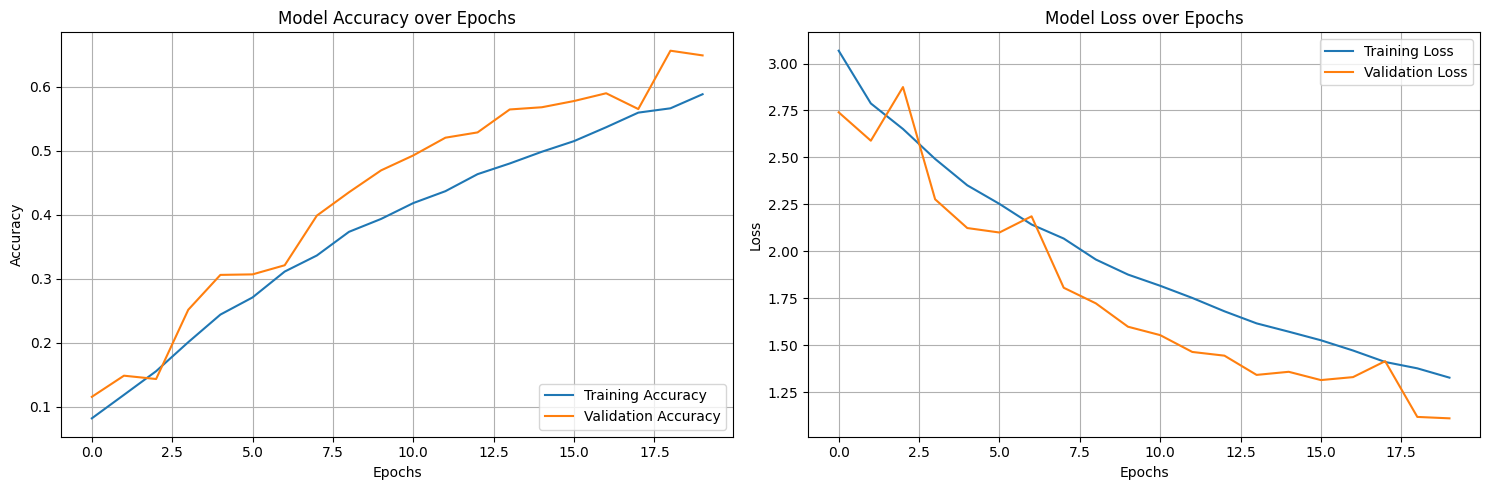

In [18]:
# Plot accuracy and loss history
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy over Epochs')
plt.legend(loc='lower right')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss over Epochs')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

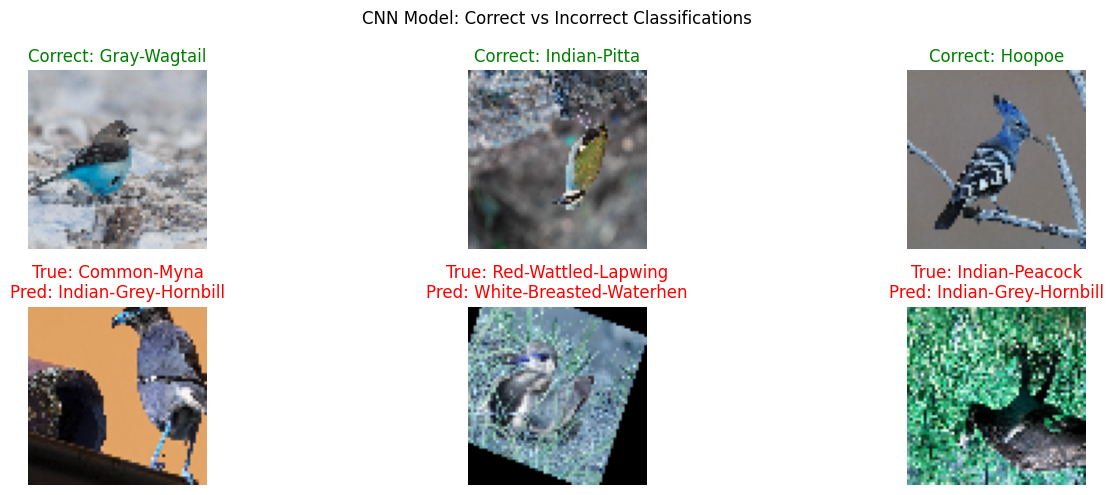

In [19]:
def plot_classification_examples(images, true_labels, predicted_labels, label_dict, title, num_correct=3, num_incorrect=3):
    correct_indices = np.where(true_labels == predicted_labels)[0]
    incorrect_indices = np.where(true_labels != predicted_labels)[0]
    
    if len(correct_indices) >= num_correct and len(incorrect_indices) >= num_incorrect:
        # Sample indices
        correct_sample = np.random.choice(correct_indices, num_correct, replace=False)
        incorrect_sample = np.random.choice(incorrect_indices, num_incorrect, replace=False)
        
        plt.figure(figsize=(15, 5))
        
        # Plot correct examples
        for i, idx in enumerate(correct_sample):
            plt.subplot(2, max(num_correct, num_incorrect), i + 1)
            plt.imshow(images[idx])
            true_label = list(label_dict.keys())[list(label_dict.values()).index(true_labels[idx])]
            plt.title(f"Correct: {true_label}", color='green')
            plt.axis('off')
        
        # Plot incorrect examples
        for i, idx in enumerate(incorrect_sample):
            plt.subplot(2, max(num_correct, num_incorrect), i + num_correct + 1)
            plt.imshow(images[idx])
            true_label = list(label_dict.keys())[list(label_dict.values()).index(true_labels[idx])]
            pred_label = list(label_dict.keys())[list(label_dict.values()).index(predicted_labels[idx])]
            plt.title(f"True: {true_label}\nPred: {pred_label}", color='red')
            plt.axis('off')
        
        plt.suptitle(title)
        plt.tight_layout()
        plt.show()

# Show CNN classification examples
plot_classification_examples(test_images, test_labels, test_predictions_labels, label_dict, 
                            "CNN Model: Correct vs Incorrect Classifications")

In [9]:
# Prepare data for KNN with PCA
print("Preparing data for KNN with PCA...")

# Flatten images for KNN
train_images_flat = train_images.reshape(len(train_images), -1)
test_images_flat = test_images.reshape(len(test_images), -1)

Preparing data for KNN with PCA...


In [10]:
# KNN Classification using scikit-learn
knn_model = KNeighborsClassifier(n_neighbors=3)
train_images_flat = train_images.reshape(len(train_images), -1)
test_images_flat = test_images.reshape(len(test_images), -1)

In [11]:
def apply_pca(X_train, X_test, n_components=None, variance_threshold=0.95):
    """Apply PCA for dimensionality reduction"""
    if n_components is None:
        # Use variance threshold to determine number of components
        pca = PCA(n_components=variance_threshold, svd_solver='full')
        pca.fit(X_train)
    else:
        # Use fixed number of components
        pca = PCA(n_components=n_components, svd_solver='full')
        pca.fit(X_train)
    
    # Transform data
    X_train_pca = pca.transform(X_train)
    X_test_pca = pca.transform(X_test)
    
    # Print info about PCA
    if n_components is None:
        print(f"PCA with {pca.n_components_} components (explaining {variance_threshold*100}% of variance)")
    else:
        explained_variance = np.sum(pca.explained_variance_ratio_)
        print(f"PCA with {n_components} components (explaining {explained_variance*100:.2f}% of variance)")
    
    return X_train_pca, X_test_pca, pca

In [12]:
# Standardize data before PCA
scaler = StandardScaler()
train_images_scaled = scaler.fit_transform(train_images_flat)
test_images_scaled = scaler.transform(test_images_flat)

In [13]:
from sklearn.decomposition import IncrementalPCA

# Apply PCA with batching to handle memory constraints
print("Fitting Incremental PCA to training data...")
try:
    # Initialize Incremental PCA
    ipca = IncrementalPCA(n_components=100)  # Start with 100 components
    
    # Process data in batches
    batch_size = 1000
    for i in range(0, len(train_images_scaled), batch_size):
        batch = train_images_scaled[i:i + batch_size]
        ipca.partial_fit(batch)
    
    # Transform data
    train_pca_data = ipca.transform(train_images_scaled)
    
    # Calculate cumulative explained variance
    cumulative_variance_ratio = np.cumsum(ipca.explained_variance_ratio_)
    
    print(f"IncrementalPCA fitted successfully with {ipca.n_components_} components")
    print(f"Explained variance ratio with {ipca.n_components_} components: {cumulative_variance_ratio[-1]:.4f}")
    
    # Store for later use
    pca_full = ipca

except Exception as e:
    print(f"Error during PCA fitting: {str(e)}")

Fitting Incremental PCA to training data...
IncrementalPCA fitted successfully with 100 components
Explained variance ratio with 100 components: 0.7371


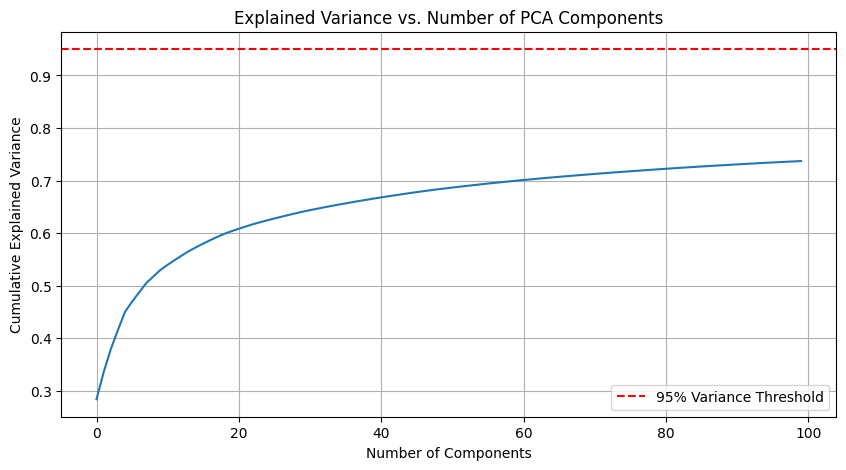

In [15]:
# Plot explained variance
plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs. Number of PCA Components')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance Threshold')
plt.legend()
plt.show()

In [16]:
# Find optimal number of components for 95% variance
n_components_95 = np.argmax(np.cumsum(pca_full.explained_variance_ratio_) >= 0.95) + 1
print(f"Number of components for 95% variance: {n_components_95}")

Number of components for 95% variance: 1


In [17]:
# Apply PCA for KNN with memory optimization
train_pca = pca_full.transform(train_images_scaled.astype(np.float32))
test_pca = pca_full.transform(test_images_scaled.astype(np.float32))

print(f"PCA transformed data shapes - Train: {train_pca.shape}, Test: {test_pca.shape}")
print(f"Total variance explained: {np.sum(pca_full.explained_variance_ratio_):.4f}")

PCA transformed data shapes - Train: (30000, 100), Test: (7500, 100)
Total variance explained: 0.7371


In [18]:
# Improved KNN approach with hyperparameter tuning
print("Performing KNN with hyperparameter tuning...")
# Grid search for optimal KNN parameters
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]  # p=1 for Manhattan, p=2 for Euclidean
}   #Manhattan does only x and y axis whereas Euclidean includes the z axis too

Performing KNN with hyperparameter tuning...


In [19]:
knn = KNeighborsClassifier()
grid_search = GridSearchCV(knn, param_grid, cv=3, n_jobs=-1, verbose=1)
grid_search.fit(train_pca, train_labels)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


GridSearchCV(cv=3, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'n_neighbors': [3, 5, 7, 9, 11], 'p': [1, 2],
                         'weights': ['uniform', 'distance']},
             verbose=1)

In [20]:
# Get best parameters
print(f"Best KNN parameters: {grid_search.best_params_}")
knn_best = grid_search.best_estimator_

Best KNN parameters: {'n_neighbors': 11, 'p': 2, 'weights': 'distance'}


In [22]:
# Evaluate KNN on test data
knn_predictions = knn_best.predict(test_pca)
knn_accuracy = accuracy_score(test_labels, knn_predictions)
print(f'KNN Accuracy with PCA: {knn_accuracy * 100:.2f}%')

KNN Accuracy with PCA: 23.89%


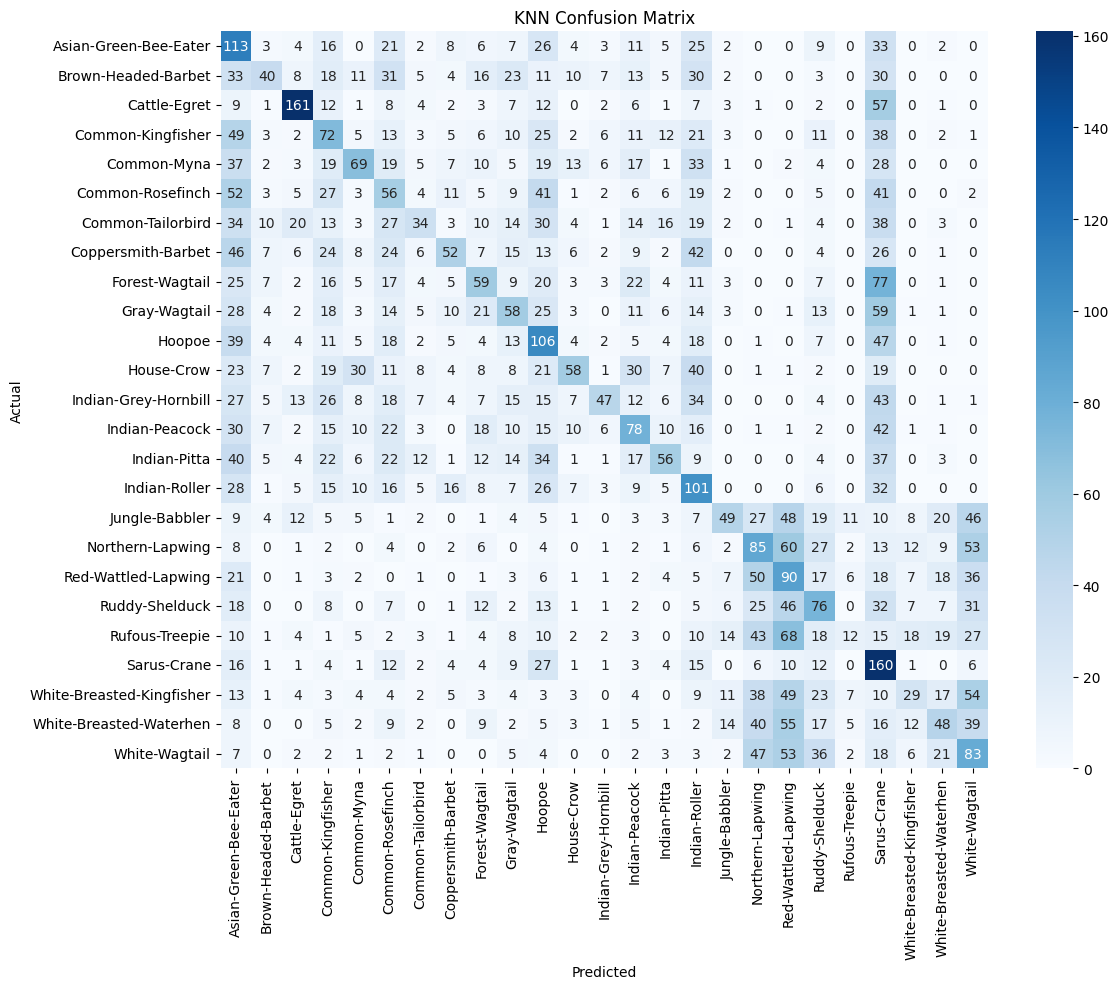

In [23]:
# Generate KNN confusion matrix
knn_conf_matrix = confusion_matrix(test_labels, knn_predictions)
plt.figure(figsize=(12, 10))
sns.heatmap(knn_conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=list(label_dict.keys()), 
            yticklabels=list(label_dict.keys()))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('KNN Confusion Matrix')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [25]:
print("KNN Classification Report:")
print(classification_report(test_labels, knn_predictions, target_names=label_dict.keys()))

KNN Classification Report:
                           precision    recall  f1-score   support

    Asian-Green-Bee-Eater       0.16      0.38      0.22       300
      Brown-Headed-Barbet       0.34      0.13      0.19       300
             Cattle-Egret       0.60      0.54      0.57       300
        Common-Kingfisher       0.19      0.24      0.21       300
              Common-Myna       0.35      0.23      0.28       300
         Common-Rosefinch       0.15      0.19      0.17       300
        Common-Tailorbird       0.28      0.11      0.16       300
       Coppersmith-Barbet       0.35      0.17      0.23       300
           Forest-Wagtail       0.25      0.20      0.22       300
             Gray-Wagtail       0.22      0.19      0.21       300
                   Hoopoe       0.21      0.35      0.26       300
               House-Crow       0.40      0.19      0.26       300
     Indian-Grey-Hornbill       0.47      0.16      0.24       300
           Indian-Peacock       0.